## Загрузка данных

In [76]:
import pandas as pd
import time
import statistics
from pathlib import Path
import matplotlib.pyplot as plt


In [77]:
from IPython.display import display, Markdown

In [78]:
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

In [79]:
file_path = "../data/interim/top_podcasts_debug.csv"

In [80]:
df = pd.read_csv(file_path)

In [81]:
display(Markdown(f"### Прочитано: `{df.shape[0]:,}` строк, `{df.shape[1]}` колонок"))

### Прочитано: `199,999` строк, `16` колонок

In [82]:
overview = pd.DataFrame({
    "Тип данных": df.dtypes,
    "Число уникальных значений": df.nunique(),
    "Доля пропусков": df.isna().mean() * 100
})

overview

,Тип данных,Число уникальных значений,Доля пропусков
date,str,46,0.000000
rank,int64,200,0.000000
region,str,22,0.000000
chartRankMove,str,4,0.000000
episodeUri,str,41502,0.000000
showUri,str,4444,0.000000
episodeName,str,41073,0.000000
description,str,38122,1.152006
show.name,str,4489,0.000000
show.publisher,str,3505,0.000000


### Сериализация

In [83]:
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)


parquet_path = processed_dir / "top_podcasts.parquet"
feather_path = processed_dir / "top_podcasts.feather"
pickle_path = processed_dir / "top_podcasts.pkl"



In [84]:
df.to_parquet(parquet_path, index=False)
df.to_feather(feather_path)
df.to_pickle(pickle_path)

#### Размер файлов

In [85]:
def get_file_size_mb(path):
    return path.stat().st_size / (1024 ** 2)

In [86]:
print("Parquet:", round(get_file_size_mb(parquet_path),4), "MB")
print("Feather:", round(get_file_size_mb(feather_path),4), "MB")
print("Pickle:", round(get_file_size_mb(pickle_path),4), "MB")



Parquet: 104.1239 MB
Feather: 125.4882 MB
Pickle: 212.1217 MB


#### Время записи


In [87]:
def measure_write_time(write_function, repeats=3):
    times = []

    for _ in range(repeats):
        start = time.perf_counter()

        write_function()

        end = time.perf_counter()
        times.append(end - start)

    return statistics.median(times)

In [88]:
parquet_write_time = measure_write_time(
    lambda: df.to_parquet(parquet_path, index=False)
)

feather_write_time = measure_write_time(
    lambda: df.to_feather(feather_path)
)

pickle_write_time = measure_write_time(
    lambda: df.to_pickle(pickle_path)
)



#### Время чтения

In [89]:
def measure_read_time(read_function, repeats=3):
    times = []

    for _ in range(repeats):
        start = time.perf_counter()

        read_function()

        end = time.perf_counter()
        times.append(end - start)

    return statistics.median(times)

In [90]:
parquet_read_time = measure_read_time(
    lambda: pd.read_parquet(parquet_path)
)

feather_read_time = measure_read_time(
    lambda: pd.read_feather(feather_path)
)

pickle_read_time = measure_read_time(
    lambda: pd.read_pickle(pickle_path)
)

In [91]:
selected_columns = ["date", "rank", "region"]

In [92]:
parquet_three_columns_read_time = measure_read_time(
    lambda: pd.read_parquet(
        parquet_path,
        columns=selected_columns
    )
)

In [93]:
results = pd.DataFrame([
    {
        "format": "Parquet",
        "file_size_mb": get_file_size_mb(parquet_path),
        "write_time_median": parquet_write_time,
        "read_time_median": parquet_read_time
    },
    {
        "format": "Feather",
        "file_size_mb": get_file_size_mb(feather_path),
        "write_time_median": feather_write_time,
        "read_time_median": feather_read_time
    },
    {
        "format": "Pickle",
        "file_size_mb": get_file_size_mb(pickle_path),
        "write_time_median": pickle_write_time,
        "read_time_median": pickle_read_time
    }
])

results

,format,file_size_mb,write_time_median,read_time_median
0,Parquet,104.123889,10.427056,0.717117
1,Feather,125.488207,18.798233,0.302982
2,Pickle,212.121748,16.892669,0.208358


In [94]:
parquet_columns_results = pd.DataFrame([
    {
        "read_type": "Весь файл",
        "time_median": parquet_read_time
    },
    {
        "read_type": "3 столбца",
        "time_median": parquet_three_columns_read_time
    }
])

parquet_columns_results

,read_type,time_median
0,Весь файл,0.717117
1,3 столбца,0.026082


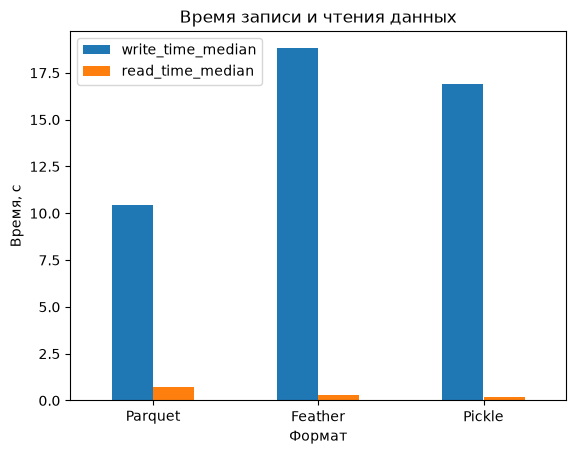

In [95]:

results.plot(
    x="format",
    y=["write_time_median", "read_time_median"],
    kind="bar"
)

plt.ylabel("Время, с")
plt.xlabel("Формат")
plt.title("Время записи и чтения данных")
plt.xticks(rotation=0)
plt.show()

В ходе эксперимента были сравнены форматы Parquet, Feather и Pickle по размеру файла, времени записи и времени чтения. Для каждого показателя использовались три измерения, а в качестве итогового значения использовалась медиана.

Формат Parquet занял 104 МБ, время записи составило 10.427056 с, а время чтения — 0.717117с. Формат Parquet показал лучший результат по размеру/скорости.

Дополнительно было проведено сравнение чтения всего файла Parquet и только трёх столбцов. Чтение трёх столбцов заняло 0.026082 с против 0.717117 с для полного файла.

Для дальнейшей работы выбран формат Parquet, поскольку для данного проекта наиболее важна быстрая обработка данных.